This notebook builds and tunes an LSTM neural network to predict the next-day closing price of Bitcoin (BTC-USD), using 30-day sequences of historical OHLCV (Open, High, Low, Close, Volume)-derived features as input. Hyperparameter tuning (layer sizes, dropout rate, learning rate) is performed with keras_tuner, and the architecture consists of three LSTM layers, a dropout layer, and dense layers.

In [2]:
!pip install tensorflow
!pip install keras
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.5 MB/s eta 0:00:00


In [3]:
import yfinance as yf
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

In [4]:
# Load data
btc_ticker = yf.Ticker("BTC-USD")
if os.path.exists("btc.csv"):
    btc = pd.read_csv("btc.csv", index_col=0)
else:
    btc = btc_ticker.history(start="2014-09-17", end="2024-09-01")
    btc.to_csv("btc.csv")

In [5]:
# Preprocess the data
btc = btc.drop(columns=["Dividends", "Stock Splits"])
btc.index = pd.to_datetime(btc.index)
btc.index = btc.index.tz_localize(None)
btc.fillna(method='ffill', inplace=True)

/tmp/ipykernel_2719/3668520929.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  btc.fillna(method='ffill', inplace=True)


In [6]:
def compute_rolling(btc):
    horizons = [2, 7, 60, 365]
    for horizon in horizons:
        rolling_averages = btc.rolling(horizon, min_periods=1).mean()
        ratio_column = f"close_ratio_{horizon}"
        btc[ratio_column] = btc["Close"] / rolling_averages["Close"]
        rolling = btc.rolling(horizon, closed='left', min_periods=1).mean()
        trend_column = f"trend_{horizon}"
        btc[trend_column] = rolling["Close"]
    btc = btc.dropna()
    return btc

btc = compute_rolling(btc)

In [7]:
# Define the features and target
features = ['Open', 'High', 'Low', 'Volume', 'close_ratio_2', 'trend_2', 'close_ratio_7', 'trend_7', 'close_ratio_60', 'trend_60', 'close_ratio_365', 'trend_365']
X = btc[features]
y = btc['Close']

In [8]:
# Normalize the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# # Split the data into training and testing sets
# train_size = int(len(X) * 0.8)
# test_size = len(X) - train_size
# X_train, X_test = X_scaled[0:train_size], X_scaled[train_size:len(X)]
# y_train, y_test = y[0:train_size], y[train_size:len(X)]

# Split the data into training, validation, and testing sets
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.1)
test_size = len(X) - train_size - val_size

X_train, X_val, X_test = X_scaled[:train_size], X_scaled[train_size:train_size+val_size], X_scaled[train_size+val_size:]
y_train, y_val, y_test = y[:train_size], y[train_size:train_size+val_size], y[train_size+val_size:]

In [10]:
y_test_index = y_test.index
y_test_index

DatetimeIndex(['2022-09-04', '2022-09-05', '2022-09-06', '2022-09-07',
               '2022-09-08', '2022-09-09', '2022-09-10', '2022-09-11',
               '2022-09-12', '2022-09-13',
               ...
               '2024-08-22', '2024-08-23', '2024-08-24', '2024-08-25',
               '2024-08-26', '2024-08-27', '2024-08-28', '2024-08-29',
               '2024-08-30', '2024-08-31'],
              dtype='datetime64[ns]', name='Date', length=728, freq=None)

In [11]:
# Reshape the data to 3D for LSTM [samples, timesteps, features]
def create_dataset(X, y, time_step=1):
    Xs, ys = [], []
    for i in range(len(X) - time_step):
        v = X[i:(i + time_step)]
        Xs.append(v)
        ys.append(y[i + time_step - 1])
    return np.array(Xs), np.array(ys)

In [12]:
# time_step = 30  # Define the number of timesteps
# X_train, y_train = create_dataset(X_train, y_train, time_step)
# X_test, y_test = create_dataset(X_test, y_test, time_step)

time_step = 30  # Define the number of timesteps
X_train, y_train = create_dataset(X_train, y_train, time_step)
X_val, y_val = create_dataset(X_val, y_val, time_step)
X_test, y_test = create_dataset(X_test, y_test, time_step)

/tmp/ipykernel_2719/52872754.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ys.append(y[i + time_step - 1])


In [13]:
# Define the model building function for Keras Tuner
def build_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('units_1', min_value=32, max_value=64, step=8), return_sequences=True, input_shape=(time_step, X_train.shape[2])))
    model.add(LSTM(units=hp.Int('units_2', min_value=32, max_value=64, step=8), return_sequences=True))
    model.add(LSTM(units=hp.Int('units_3', min_value=32, max_value=64, step=8)))
    model.add(Dropout(hp.Float('dropout', min_value=0.1, max_value=0.3, step=0.1)))
    model.add(Dense(units=hp.Int('dense_units_1', min_value=16, max_value=64, step=8), activation="relu"))
    model.add(Dense(units=hp.Int('dense_units_2', min_value=16, max_value=64, step=8), activation="relu"))
    model.add(Dense(1))

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  loss='mean_squared_error')
    return model

In [14]:
# Initialize the Keras Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=50,
    executions_per_trial=1,
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
# Stop early if the model is not improving
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Search for the best hyperparameters
tuner.search(X_train, y_train, epochs=50, validation_data=(X_val, y_val), callbacks=[early_stopping])

# Get the best model
best_tuner_model = tuner.get_best_models(num_models=1)[0]

Trial 50 Complete [00h 00m 58s]
val_loss: 1484328192.0

Best val_loss So Far: 1393880.0
Total elapsed time: 00h 35m 57s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 32 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [16]:
best_hyperparameters = best_tuner_model.get_config()
print(best_hyperparameters)

{'name': 'sequential', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': (None, 30, 12), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'input_layer', 'optional': False}, 'registered_name': None}, {'module': 'keras.layers', 'class_name': 'LSTM', 'config': {'name': 'lstm', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'return_sequences': True, 'return_state': False, 'go_backwards': False, 'stateful': False, 'unroll': False, 'zero_output_for_mask': False, 'units': 32, 'activation': 'tanh', 'recurrent_activation': 'sigmoid', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'recurrent_initializer': {'module': '

In [17]:
best_tuner_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 32)         │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,233 (184.50 KB)

 Trainable params: 47,233 (184.50 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
def find_best_model(model, X_train, y_train, X_test, y_test, X_val, y_val):
    best_mae = float("inf")
    best_model = None
    best_batch = None
    best_epochs = None
    best_y_pred = None

    for batch in [4, 8, 12, 16, 32, 64, 128, 256, 512]:
            # Create a new instance of the model for each combination
            model_copy = tf.keras.models.clone_model(model)
            model_copy.set_weights(model.get_weights())

            # Reinitialize the optimizer
            optimizer = tf.keras.optimizers.Adam()

            # Compile the cloned model with the new optimizer
            model_copy.compile(optimizer=optimizer, loss=model.loss)

            early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
            # Train the model
            history = model_copy.fit(X_train, y_train, batch_size=batch, epochs=250, validation_data=(X_val, y_val), callbacks=[early_stopping])

            # Retrieve the number of epochs the model was trained for
            epochs_trained = len(history.history['loss'])

            # Predict on the test set
            y_pred = model_copy.predict(X_test)

            # Calculate MAE
            mae = mean_absolute_error(y_test, y_pred)
            mse_lstm = mean_squared_error(y_test, y_pred)
            rmse_lstm = np.sqrt(mse_lstm)
            r2_lstm = r2_score(y_test, y_pred)

            print(f"Mean Absolute Error: {mae}")
            print(f"Mean Squared Error: {mse_lstm}")
            print(f"Root Mean Squared Error: {rmse_lstm}")
            print(f"R-squared: {r2_lstm}")

            # Check if this is the best model
            if mae < best_mae:
                best_mae = mae
                best_model = model_copy
                best_batch = batch
                best_epochs = epochs_trained
                best_y_pred = y_pred

            print(f"Batch size: {batch}, Epochs: {epochs_trained}, MAE: {mae}")

    print(f"\nBest Batch size: {best_batch}, Best Epochs: {best_epochs}, Best MAE: {best_mae}")

    return best_model, best_batch, best_epochs, best_y_pred

In [19]:
best_lstm_model, best_batch, best_epochs, y_pred = find_best_model(best_tuner_model, X_train, y_train, X_test, y_test, X_val, y_val)

Epoch 1/250
629/629 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 1715785.7500 - val_loss: 9419432.0000
Epoch 2/250
629/629 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 1624640.5000 - val_loss: 11793721.0000
Epoch 3/250
629/629 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 1532355.3750 - val_loss: 3628602.7500
Epoch 4/250
629/629 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 1401947.3750 - val_loss: 14773943.0000
Epoch 5/250
629/629 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 1389067.6250 - val_loss: 4784800.0000
Epoch 6/250
629/629 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 1603472.3750 - val_loss: 6079732.5000
Epoch 7/250
629/629 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 1460644.5000 - val_loss: 4715605.5000
Epoch 8/250
629/629 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 1355410.3750 - val_loss: 6782536.5000
Epoch 9/250
629/629 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 1256805.0000 - val_loss: 21481372.0000
Epoch 10/250
629/629 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 1703432.6250 - val_loss: 6129999.

In [20]:
# Evaluate the model
mae_lstm = mean_absolute_error(y_test, y_pred)
mse_lstm = mean_squared_error(y_test, y_pred)
rmse_lstm = np.sqrt(mse_lstm)
r2_lstm = r2_score(y_test, y_pred)

print(f"LSTM - Mean Absolute Error: {mae_lstm}")
print(f"LSTM - Mean Squared Error: {mse_lstm}")
print(f"LSTM - Root Mean Squared Error: {rmse_lstm}")
print(f"LSTM - R^2: {r2_lstm}")

LSTM - Mean Absolute Error: 800.7220994135029
LSTM - Mean Squared Error: 2641252.118362771
LSTM - Root Mean Squared Error: 1625.1929480411768
LSTM - R^2: 0.9915211993685698


In [21]:
# Reshape y_test and y_pred to 2D arrays for the scaler
y_test_reshaped = np.array(y_test).reshape(-1, 1)
y_pred_reshaped = np.array(y_pred).reshape(-1, 1)

# Min-Max scale y_test and y_pred
scaler = StandardScaler()
y_test_scaled = scaler.fit_transform(y_test_reshaped)
y_pred_scaled = scaler.transform(y_pred_reshaped)

# Calculate the metrics on the scaled data
mae_scaled_lstm = mean_absolute_error(y_test_scaled, y_pred_scaled)
mse_scaled_lstm = mean_squared_error(y_test_scaled, y_pred_scaled)
rmse_scaled_lstm = np.sqrt(mse_scaled_lstm)
r2_scaled_lstm = r2_score(y_test_scaled, y_pred_scaled)

print(f"LSTM - Scaled Mean Absolute Error: {mae_scaled_lstm}")
print(f"LSTM - Scaled Mean Squared Error: {mse_scaled_lstm}")
print(f"LSTM - Scaled Root Mean Squared Error: {rmse_scaled_lstm}")
print(f"LSTM - Scaled R^2: {r2_scaled_lstm}")

LSTM - Scaled Mean Absolute Error: 0.045367416619208255
LSTM - Scaled Mean Squared Error: 0.008478799382412874
LSTM - Scaled Root Mean Squared Error: 0.09208039629808765
LSTM - Scaled R^2: 0.9915212006175871


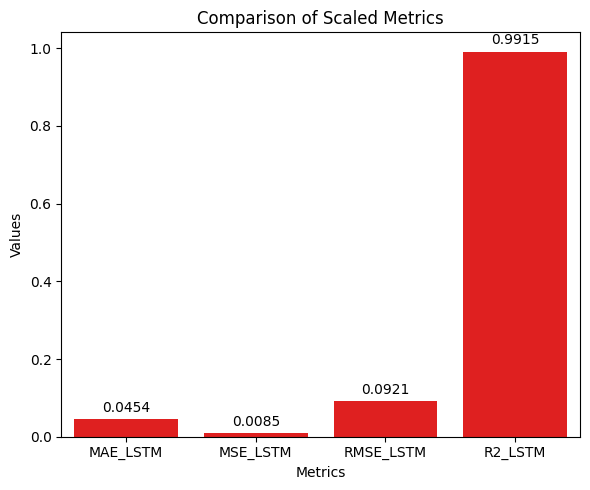

In [22]:
# Prepare data for plotting
metrics = ['MAE_LSTM', 'MSE_LSTM', 'RMSE_LSTM', 'R2_LSTM']
scaled_values = [mae_scaled_lstm, mse_scaled_lstm, rmse_scaled_lstm, r2_scaled_lstm]

# Create a DataFrame for better visualization with Seaborn
metrics_df = pd.DataFrame({'Metric': metrics, 'Value': scaled_values})

# Plotting the scaled metrics using seaborn
plt.figure(figsize=(6, 5))
sns.barplot(x='Metric', y='Value', data=metrics_df, color="red")

# Add some text for labels and title
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Comparison of Scaled Metrics')

# Function to label the bars
def autolabel(rects, ax):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height, 4)),  # rounded to 4 decimal places for better precision
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

# Get the current Axes instance
ax = plt.gca()

# Apply the autolabel function
rects = ax.patches
autolabel(rects, ax)

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Date')

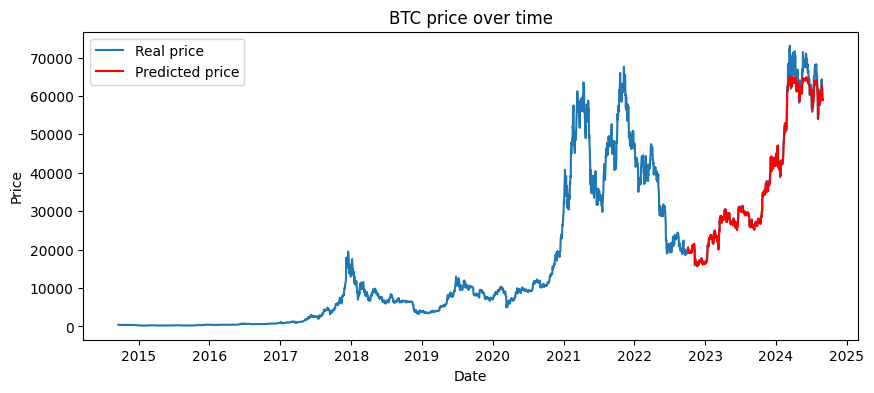

In [23]:
y_pred_series = pd.Series(y_pred.flatten(), index=y_test_index[30:])
# y_pred = y_pred.sort_index()
# print(best_y_pred)

plt.figure(figsize=(10,4))

# Add title
plt.title("BTC price over time")

# Line chart
sns.lineplot(data=btc["Close"], label="Real price")

# Line chart
sns.lineplot(data=y_pred_series, label="Predicted price", color="red")

# Add legend
plt.legend()

# Add label for vertical axis
plt.ylabel("Price")

# Add label for horizontal axis
plt.xlabel("Date")

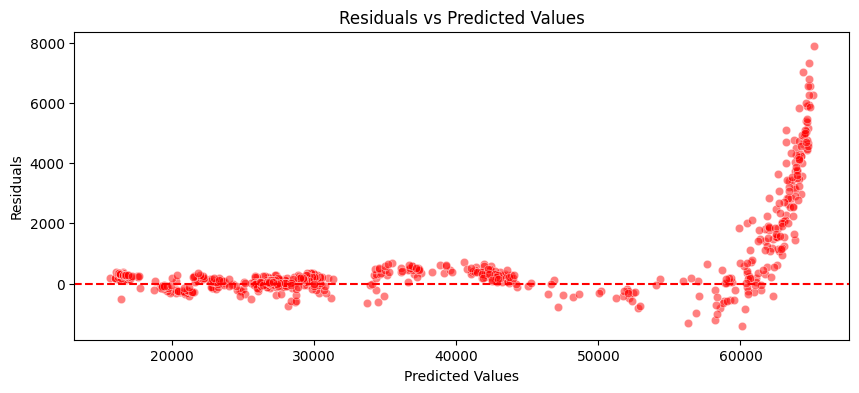

In [24]:
# Calculate residuals
residuals = y_test - y_pred_series

# Plot residuals using seaborn
plt.figure(figsize=(10, 4))
sns.scatterplot(x=y_pred_series, y=residuals, alpha=0.5, color="red")
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

In [25]:
compare = pd.DataFrame({'y_test': y_test[2:], 'y_pred_lstm': y_pred.flatten()[2:]}, index=y_test_index[32:])
compare

,y_test,y_pred_lstm
Date,,
2022-10-06,20160.716797,20368.566406
2022-10-07,19955.443359,20256.984375
2022-10-08,19546.849609,19852.841797
2022-10-09,19416.568359,19660.806641
2022-10-10,19446.425781,19599.318359
...,...,...
2024-08-27,62880.660156,62327.332031
2024-08-28,59504.132812,60335.960938
2024-08-29,59027.625000,58995.507812


In [26]:
import pickle
# Save the Series to files

with open('scaled_values_lstm.pkl', 'wb') as f:
    pickle.dump(scaled_values, f)
with open('y_pred_lstm.pkl', 'wb') as f:
    pickle.dump(y_pred, f)
with open('residuals_lstm.pkl', 'wb') as f:
    pickle.dump(residuals, f)
with open('y_test_index.pkl', 'wb') as f:
    pickle.dump(y_test_index, f)

In [27]:
%history

import yfinance as yf
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
!pip install tensorflow
!pip install keras
!pip install keras-tuner
import yfinance as yf
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplot